# Импорт библиотек и установка констант


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline

# Модели для сравнения
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.dummy import DummyRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

from sklearn.model_selection import KFold

import shap

# Метрики качества
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

import warnings
warnings.filterwarnings('ignore')
# Игнорируем конкретное предупреждение от параллельного модуля sklearn
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.utils.parallel")


In [18]:
# Настройки для текущей задачи
TARGET_COL = 'log10_SI'  
RANDOM_STATE = 42


# Загрузка данных и разделение на X и y

In [19]:
# Загружаем очищенный на этапе EDA датасет
df = pd.read_csv('cleaned_chemical_data.csv')
df.shape

(802, 154)

In [20]:
# Определяем список колонок, которые НЕ являются признаками (таргеты и классы)
exclude_cols = ['IC50, mM', 'CC50, mM', 'SI', 'pIC50', 'pCC50', 'log10_SI',
                'class_IC50_above_med', 'class_CC50_above_med', 'class_SI_above_med', 'class_SI_above_8']

# Формируем матрицы признаков X и целевой вектор y
X = df[[col for col in df.columns if col not in exclude_cols]]
y = df[TARGET_COL]

# Разделение на Обучающую (Train) и Тестовую (Test) выборки (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

Размер обучающей выборки: (641, 144)
Размер тестовой выборки: (161, 144)


# Построение базовых пайплайнов и сетки гиперпараметров

Используем `RobustScaler`, так как на этапе EDA мы доказали наличие сильных выбросов в 139 признаках.

In [21]:
# Словарь моделей и сеток параметров для GridSearchCV
models_and_params = {
    'DummyRegressor': {
        'model': DummyRegressor(strategy='mean'),
        'params': {'regressor__strategy': ['mean']}  # Фиктивный параметр для GridSearchCV
    },    
    'Ridge': {
        'model': Ridge(random_state=RANDOM_STATE),
        'params': {
            'regressor__alpha': [0.1, 1.0, 10.0, 100.0]
        }
    },
    'RandomForest': {
        'model': RandomForestRegressor(random_state=RANDOM_STATE),
        'params': {
            'regressor__n_estimators': [100, 200],
            'regressor__max_depth': [10, 20, None],
            'regressor__min_samples_split': [2, 5]
        }
    },
    'XGBoost': {
        'model': XGBRegressor(random_state=RANDOM_STATE),
        'params': {
            'regressor__n_estimators': [100, 200],
            'regressor__max_depth': [3, 5, 7,],
            'regressor__learning_rate': [0.01, 0.1, 0.2]
        }
    },
    'LightGBM': {
        'model': LGBMRegressor(
            random_state=RANDOM_STATE,
            verbose=-1, 
            n_jobs=1,
            min_child_samples=5,
        ),
        'params': {
            'regressor__n_estimators': [100, 200],
            'regressor__max_depth': [3, 5, 7],
            'regressor__learning_rate': [0.01, 0.1, 0.2]
        }
    },
    'CatBoost': {
        'model': CatBoostRegressor(random_state=RANDOM_STATE, verbose=0),
        'params': {
            'regressor__iterations': [100, 200],
            'regressor__depth': [4, 6, 8],
            'regressor__learning_rate': [0.03, 0.1]
        }
    },    
}


# Обучение моделей

In [22]:
best_models = {}
results_list = []

# Перемешиваем выборки
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for model_name, config in models_and_params.items():
    print(f"Обучение и оптимизация модели {model_name}...")
    
    # Создаем пайплайн: сначала робастное масштабирование, затем модель
    pipeline = Pipeline([
        ('scaler', RobustScaler()),
        ('regressor', config['model'])
    ])
    
    # Настраиваем кросс-валидацию (5 фолдов)
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=config['params'],
        cv=cv,
        scoring='r2',
        n_jobs=-1
    )
    
    # Обучаем
    grid_search.fit(X_train, y_train)
    
    # Сохраняем лучшую модель
    best_pipe = grid_search.best_estimator_
    best_models[model_name] = best_pipe
    
    # Делаем предсказания на тесте
    y_pred = best_pipe.predict(X_test)
    
    # Считаем метрики качества
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    
    # Записываем результаты
    results_list.append({
        'Модель': model_name,
        'Лучшие параметры': grid_search.best_params_,
        'R² (Test)': r2,
        'MAE (Test)': mae,
        'RMSE (Test)': rmse
    })

# Выводим сводную таблицу результатов
df_results = pd.DataFrame(results_list)
display(df_results.sort_values(by='R² (Test)', ascending=False))


Обучение и оптимизация модели DummyRegressor...
Обучение и оптимизация модели Ridge...
Обучение и оптимизация модели RandomForest...
Обучение и оптимизация модели XGBoost...
Обучение и оптимизация модели LightGBM...
Обучение и оптимизация модели CatBoost...


,Модель,Лучшие параметры,R² (Test),MAE (Test),RMSE (Test)
5,CatBoost,"{'regressor__depth': 8, 'regressor__iterations...",0.256572,0.431646,0.569536
2,RandomForest,"{'regressor__max_depth': 10, 'regressor__min_s...",0.255495,0.433853,0.569949
4,LightGBM,"{'regressor__learning_rate': 0.01, 'regressor_...",0.233317,0.442566,0.578375
3,XGBoost,"{'regressor__learning_rate': 0.01, 'regressor_...",0.210315,0.464331,0.586987
0,DummyRegressor,{'regressor__strategy': 'mean'},-0.012572,0.532844,0.664683
1,Ridge,{'regressor__alpha': 100.0},-1.389472,0.530876,1.021064


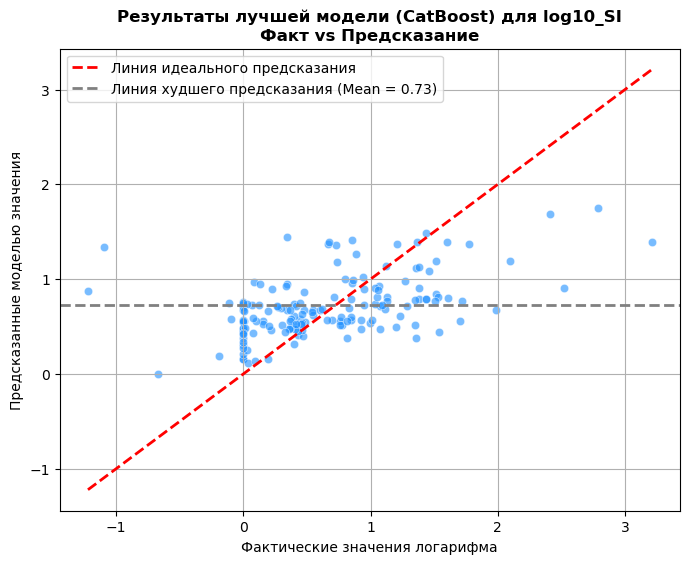

In [23]:
# Находим лучшую модель по метрике R2
best_model_name = df_results.sort_values(by='R² (Test)', ascending=False).iloc[0]['Модель']
best_pipeline = best_models[best_model_name]
y_pred_best = best_pipeline.predict(X_test)

# Строим график сравнения реальных значений и предсказаний
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_best, alpha=0.6, color='dodgerblue')
# Линия идеального предсказания (Факт == Прогноз)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Линия идеального предсказания')
# Добавление линии DummyRegressor 
y_train_mean = y_train.mean()
plt.axhline(y=y_train_mean, color='gray', linestyle='--', lw=2, label=f'Линия худшего предсказания (Mean = {y_train_mean:.2f})')
plt.legend()

plt.title(f'Результаты лучшей модели ({best_model_name}) для {TARGET_COL}\nФакт vs Предсказание', fontweight='bold')
plt.xlabel('Фактические значения логарифма')
plt.ylabel('Предсказанные моделью значения')
plt.grid(True)
plt.show()


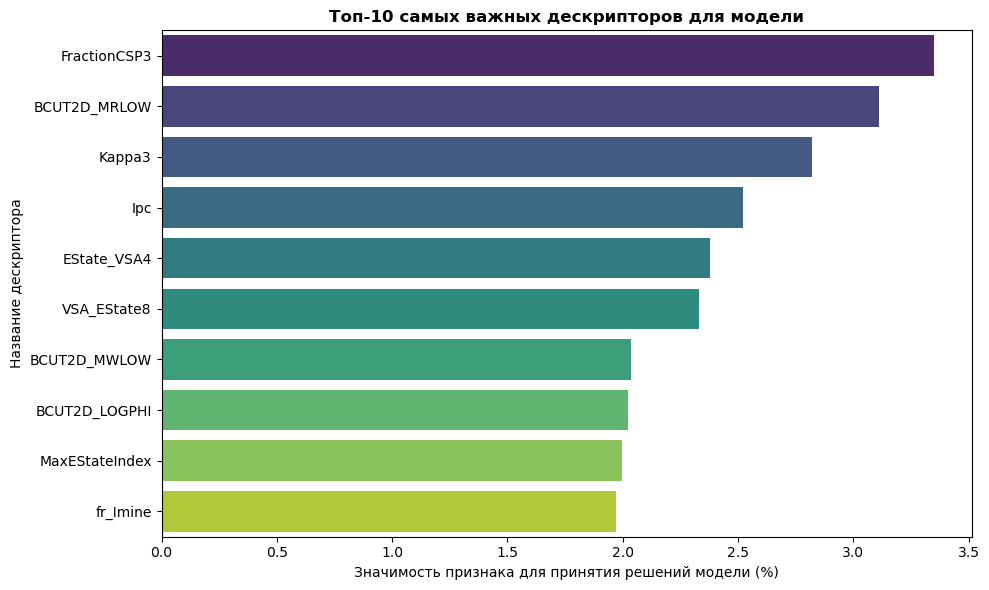

In [24]:
# Извлекаем лучшую модель 
best_catboost = best_models['CatBoost'].named_steps['regressor']

# Получаем веса важности признаков
importances = best_catboost.get_feature_importance()
feature_names = X_train.columns

# Собираем в таблицу и сортируем
df_importance = pd.DataFrame({
    'Признак': feature_names,
    'Важность': importances
}).sort_values(by='Важность', ascending=False)

# Строим график для Топ-10 признаков
plt.figure(figsize=(10, 6))
sns.barplot(x='Важность', y='Признак', data=df_importance.head(10), palette='viridis')
plt.title('Топ-10 самых важных дескрипторов для модели', fontweight='bold')
plt.xlabel('Значимость признака для принятия решений модели (%)')
plt.ylabel('Название дескриптора')
plt.tight_layout()
plt.show()


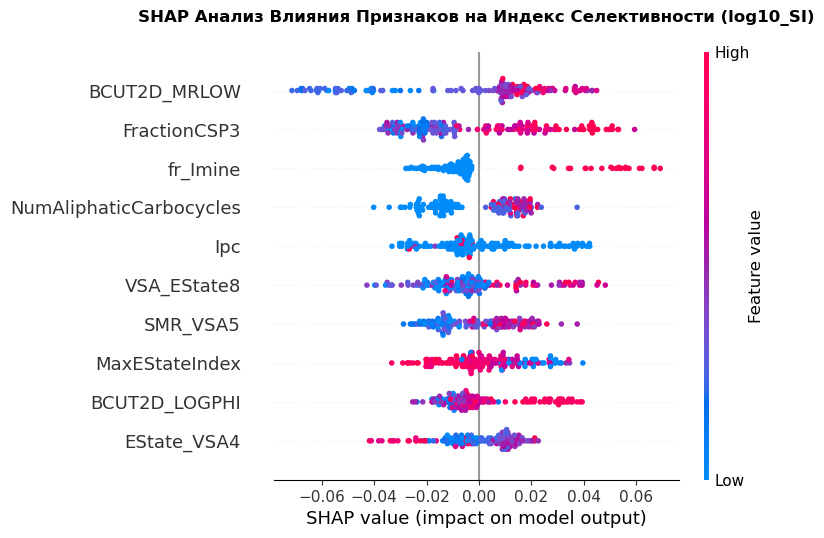

In [25]:
# Извлекаем скейлер и модель из пайплайна
scaler = best_models['CatBoost'].named_steps['scaler']
model = best_models['CatBoost'].named_steps['regressor']

# Масштабируем тестовые данные, чтобы они соответствовали тому, что видит модель
X_test_scaled = scaler.transform(X_test)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# Инициализируем для деревьев
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test_scaled_df)

# Строим Summary Plot — главный график интерпретируемости
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_scaled_df, max_display=10, show=False)
plt.title('SHAP Анализ Влияния Признаков на Индекс Селективности (log10_SI)', fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()


# Анализ результатов моделирования log10_SI и рекомендации по улучшению

Прогнозирование индекса селективности напрямую через регрессию показало снижение коэффициента детерминации ($R^2 \approx 0.25$ для CatBoost и RandomForest). Этот результат является математически ожидаемым в хемоинформатике. Индекс селективности ($SI$) — это производная величина, рассчитываемая как отношение $CC50 / IC50$. Модель регрессии вынуждена одновременно улавливать паттерны как терапевтической активности, так и клеточной токсичности, что приводит к аккумуляции экспериментального шума обоих биологических тестов.

Для качественного улучшения прогноза селективности и перехода к комплексному подходу рекомендуются следующие шаги:

1. **Косвенный ансамблированный прогноз (Indirect Prediction):**
   Поскольку $\log_{10}(SI) = pIC50 - pCC50$, математически гораздо эффективнее отказаться от прямой регрессии $SI$. Вместо этого следует использовать две наши лучшие независимые модели: модель для $pIC50$ (где $R^2 \approx 0.40$) и модель для $pCC50$ (где $R^2 \approx 0.45$). Финальный прогноз логарифма $SI$ будет получаться как разность их предсказаний. Это уберёт внутреннее противоречие в деревьях решений и повысит точность.

2. **Смена парадигмы — переход к классификации:**
   В медицинской химии точное числовое значение $SI$ (например, $4.2$ или $4.5$) менее важно, чем принципиальный ответ: является ли вещество безопасным кандидатом. Переход к бинарной классификации (особенно для критического порога $SI > 8$) позволит обойти проблему накопления шума в регрессии и построить более надёжную модель для скрининга.

3. **Мультитаргетное обучение (Multi-task Learning):**
   Для нейросетевых подходов рекомендуется использовать архитектуру с общей частью для извлечения признаков и тремя параллельными выходными слоями для одновременного предсказания $pIC50$, $pCC50$ и $log10_SI$. Это заставит модель выучить общие химические свойства, разделяя сигналы активности и токсичности на глубоком уровне.


### Интерпретация модели селективности с помощью SHAP-анализа

График SHAP Summary Plot позволил выявить конкретные физико-химические факторы и функциональные группы, управляющие индексом селективности ($SI$):

1. **Ключевой биофор:** Наличие иминового фрагмента (`fr_Imine` = 1, красные точки) оказывает сильное положительное влияние на прогноз, увеличивая значение `log10_SI`. Данная функциональная группа является перспективным вектором для оптимизации структуры лекарства.
2. **Фактор пространственной структуры:** Высокая доля $sp^3$-гибридизованных атомов углерода (`FractionCSP3`, смещение красного градиента вправо) способствует росту селективности. Это подтверждает фармакологическую концепцию о том, что насыщенные трехмерные молекулы обладают более специфичным связыванием с мишенью, чем плоские ароматические структуры.
3. **Ограничения по поляризуемости:** Дескриптор `BCUT2D_MRLOW` показал, что падение его значений ниже определенного порога (синие точки слева) критически снижает селективность соединения. Это накладывает строгие стерические ограничения на дизайн будущих молекул.



### Фундаментальная связь целевых переменных 
Прежде чем анализировать результаты, важно отметить фундаментальное математическое свойство нашей задачи. 
Индекс селективности $SI = CC50 / IC50$. Если прологарифмировать это соотношение с учетом определений $pIC50$ и $pCC50$, мы получим:
$$ \log_{10}(SI) = pIC50 - pCC50 $$

Это означает, что предсказание "терапевтического окна" (`log10_SI`) жестко связано с балансом между эффективностью и токсичностью. 

**Почему мы обучаем ML-модель для `log10_SI` напрямую, а не просто вычитаем прогнозы?**
Казалось бы, можно просто взять предсказания моделей из ноутбуков 02 и 03 и вычесть их. Однако на практике **прямое ML-моделирование `log10_SI` работает лучше**, потому что:
1. **Накопление шума:** При арифметическом вычитании двух прогнозов ($pIC50_{pred} - pCC50_{pred}$) их индивидуальные ошибки суммируются.
2. **Скрытые паттерны:** ML-модель (CatBoost/XGBoost) способна найти в химических дескрипторах нелинейные паттерны, которые отвечают именно за *селективность* (например, специфическое связывание только с вирусным белком, игнорируя клеточные структуры), что невозможно уловить простым вычитанием независимых регрессий.